# Options Pricing Project

### Setup

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from BS_solver import BS_solver_crank_nicholson, BS_solver_binomial_tree

### Black-Scholes Derivation

We will begin with a derivation of the Black-Scholes equation, from now on abbreviated to BS. The key assumptions are:

- Constant volatility, $\sigma$
- Constant risk-free interest rate, $r$
- Stock prices follow a geometric Brownian motion (GBM)
- No dividends are paid out

Under these assumptions, we begin with modelling the stock price as a stochastic process. Since it follows A GBM, it must satisy the stochastic differential equation (SDE)
$$
dS = \mu S + \sigma S dB,
$$
where $\mu$ is some drift parameter. The value of an option, $V$, depends only on time and the stock price, thus $V=V(S,t)$. Applying Itô's lemma to $V$, we find that
$$
dV = \frac{\partial V}{\partial t} dt + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} dt + \frac{\partial V}{\partial S} dS
$$
Now, at the same time as doing this we shall consider a delta-hedged portfolio, $\Pi$, consisting of longing a single option and shorting $\Delta$ shares of the underlying stock. We thus have
$$
\Pi = V - \Delta S.
$$
It follows then that any incremental change in the portfolio's value is given by
$$
\begin{align*}
    d\Pi &= dV - \Delta dS \\
    & = \frac{\partial V}{\partial t} dt + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} dt + \frac{\partial V}{\partial S} dS - \Delta dS
\end{align*}
$$
The entire purpose of delta-hedging is to eliminate any dependency of the portfolio's value on changes in the underlying stock, thus it is necessary to choose $\Delta = \frac{\partial V}{\partial S}$ leaving us with
$$
d\Pi = \frac{\partial V}{\partial t} dt + \frac{1}{2}\sigma^2 S^2\frac{\partial^2 V}{\partial S^2} dt
$$
only. Now that we have eliminated any dependency on the underlying stock, the only change in the portfolio's value should be due to interest. We should thus have, for an incremental time step,
$$
d\Pi = r\Pi \, dt = rV \, dt - rS\frac{\partial V}{\partial S} dt.
$$
Equating these two separate expressions for $d\Pi$ yields
$$
\begin{align*}
    &rV \, dt - rS\frac{\partial V}{\partial S} dt = \frac{\partial V}{\partial t} dt + \frac{1}{2}\sigma^2 S^2\frac{\partial^2 V}{\partial S^2} dt \\
    \implies &rV = \frac{\partial V}{\partial t} + rS\frac{\partial V}{\partial S} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2},
\end{align*}
$$
and we have our desired result, the BS equation.

In the case of a call option with strike price $K$, the expected payoff at maturity is $\max{(S-K, 0)}$, thus we must impose the terminal condition $V(S,T) = \max{(S-K, 0)}$ where $T$ is the maturity date. We also require that $V(0,t)=0$ for all $t$ since a stock of no value cannot grow under a GBM. Similarly, we impose the far field condition $V \sim S-Ke^{-r(T-t)}$ as $S \rightarrow \infty$ since for sufficiently large stock prices, the option will almost certainly be exercised.

In the case of a put option the corresponding conditions are
$$
V(S,t) \sim 0 \text{ as } S\rightarrow \infty, \\
V(0,t) = Ke^{-r(T-t)}, \\
V(S,T) = \max{(K-S, 0)}.
$$

### Transformation to Heat Equation

The BS equation does, in fact, have an analytical solution. To see this, we use the substitution
$$
\tau = \frac{\sigma^2}{2}(T-t), \quad x = \ln\bigg(\frac{S}{K}\bigg) + \bigg(r-\frac{\sigma^2}{2}\bigg)(T-t), \quad u(x, \tau) = Ve^{2r\tau/\sigma^2}.
$$
By the chain rule, we have
$$
\begin{align*}
    \frac{\partial}{\partial t} &= \frac{\partial x}{\partial t}\frac{\partial}{\partial x} + \frac{\partial \tau}{\partial t}\frac{\partial}{\partial \tau} = \bigg(\frac{\sigma^2}{2} - r\bigg)\frac{\partial}{\partial x} - \frac{\sigma^2}{2}\frac{\partial}{\partial \tau}, \\
    \frac{\partial}{\partial S} &= \frac{\partial x}{\partial S}\frac{\partial}{\partial x} + \frac{\partial \tau}{\partial S}\frac{\partial}{\partial \tau} = \frac{1}{S}\frac{\partial}{\partial x}.
\end{align*}
$$
We may thus rewrite the BS equation as
$$
\begin{align*}
    rue^{-2r\tau/\sigma^2} &= \bigg(\frac{\sigma^2}{2} - r\bigg)\frac{\partial (ue^{-2r\tau/\sigma^2})}{\partial x} - \frac{\sigma^2}{2}\frac{\partial (ue^{-2r\tau/\sigma^2})}{\partial \tau} + r \frac{\partial (ue^{-2r\tau/\sigma^2})}{\partial x} + \frac{\sigma^2 S}{2}\frac{\partial}{\partial x}\bigg( \frac{1}{S}\frac{\partial (ue^{-2r\tau /\sigma^2})}{\partial x}\bigg) \\

    rue^{-2r\tau/\sigma^2} &= e^{-2r\tau/\sigma^2}\bigg(\frac{\sigma^2}{2} - r\bigg)\frac{\partial u}{\partial x} - e^{-2r\tau/\sigma^2}\frac{\sigma^2}{2}\frac{\partial u}{\partial \tau} + rue^{-2r\tau/\sigma^2} + re^{-2r\tau/\sigma^2} \frac{\partial u}{\partial x} - e^{-2r\tau/\sigma^2}\frac{\sigma^2}{2}\frac{\partial u}{\partial x} + e^{-2r\tau/\sigma^2}\frac{\sigma^2}{2}\frac{\partial^2u}{\partial x^2} \\

    \frac{\partial u}{\partial \tau}  &=  \frac{\partial^2u}{\partial x^2},
\end{align*}
$$
which we recognise as the well-known heat equation. The corresponding transformed boundary conditions are
$$
\lim_{x\rightarrow -\infty} u(x,\tau) = 0, \\
u(x, \tau) \sim K(e^{x+\tau}-1) \text{ as } x\rightarrow \infty, \\
u(x,0) = K(e^x-1)H(x),
$$
where $H(x)$ is the Heaviside step function.

For a put option, the corresponding conditions are
$$
\lim_{x\rightarrow \infty} u(x, \tau) = 0, \\
u(x,\tau) \sim K(1-e^{x+\tau}) \text{ as } x \rightarrow -\infty, \\
u(x, 0) = K(1-e^x)H(-x).
$$


### Analytical Solution

Since this heat equation is defined on an unbounded spatial domain, we use the standard method of taking the convolution of the initial condition with the fundamental solution of the heat equation. In the 1D case, as applies here, we have
$$
\begin{align*}
    u(x, \tau) &= \frac{1}{(4\pi\tau)^{\frac{1}{2}}} \int_{-\infty}^\infty K(e^y-1)H(y)e^{-\frac{(x-y)^2}{4\tau}} dy \\
    &= \frac{K}{(4\pi\tau)^{\frac{1}{2}}} \int_0^\infty (e^y-1) e^{-\frac{(x-y)^2}{4\tau}} dy \\
    &= \frac{K}{(4\pi\tau)^{\frac{1}{2}}} \bigg( I_1 - I_2\bigg)
\end{align*}
$$
where $I_1=\int_0^\infty e^{y-\frac{(x-y)^2}{4\tau}} dy$ and $I_2 = \int_0^\infty e^{-\frac{(x-y)^2}{4\tau}} dy$. We compute these integrals in turn. By completing the square in the exponent we have
$$
\begin{align*}
    I_1 &= \int_0^\infty \exp\bigg(\frac{4\tau y - x^2 - y^2 +2xy}{4\tau}\bigg) dy \\
    &= e^{\tau + x}\int_0^\infty \exp\bigg(-\frac{(y-(2\tau+x))^2}{4\tau}\bigg) dy.
\end{align*}
$$
The substitution $z=\frac{y-(2\tau+x)}{\sqrt{2\tau}}$ yields
$$
\begin{align*}
    I_1 &= \sqrt{2\tau} e^{\tau + x} \int_{-\frac{2\tau + x}{\sqrt{2\tau}}}^\infty e^{-\frac{z^2}{2}} dz \\
    &= \sqrt{4\pi\tau} e^{\tau + x} \Phi\bigg(\frac{2\tau + x}{\sqrt{2\tau}}\bigg),
\end{align*}
$$
where $\Phi$ is the CDF of a standard normal random variable and the last line follows from the symmetry of a standard normal distribution about $0$. The remaining integral is computed using the substitution $z=\frac{x-y}{\sqrt{2\tau}}$ which yields
$$
I_2 = -\sqrt{2\tau}\int_{\frac{x}{\sqrt{2\tau}}}^{-\infty} e^{-\frac{z^2}{2}} dz = \sqrt{4\pi\tau}\Phi\bigg(\frac{x}{\sqrt{2\pi}}\bigg).
$$
Again, the last equality follows from the symmetrical properties of a standard normal PDF. Combining these results we see that
$$
u(x,\tau) = K\Bigg( e^{\tau+x}\Phi\bigg(\frac{2\tau + x}{\sqrt{2\tau}}\bigg) - \Phi\bigg(\frac{x}{\sqrt{2\pi}}\bigg)\Bigg).
$$
In terms of the original variables, this is
$$
V(S,t) = S\Phi\bigg(\frac{\ln(\frac{S}{K})+(r+\frac{\sigma^2}{2})(T-t)}{\sigma \sqrt{T-t}} \bigg) - Ke^{-r(T-t)}\Phi\bigg(\frac{\ln(\frac{S}{K}) + (r-\frac{\sigma^2}{2})(T-t)}{\sigma\sqrt{T-t}} \bigg),
$$
which is our desired analytic solution to the BS equation.

In the case of a put option, the analysis is very similar. We note that the only difference is in the boundary and initial conditions. We find instead that
$$
u(x,\tau) = \frac{K}{(4\pi\tau)^{\frac{1}{2}}} \bigg( J_1 - J_2\bigg),
$$
where
$$
\begin{align*}
    J_1 &= \int_{-\infty}^0 e^{-\frac{(x-y)^2}{4\tau}} dy = \sqrt{4\tau \pi} \Phi\bigg( - \frac{x}{\sqrt{2\tau}} \bigg), \\
    J_2 &= \int_{-\infty}^0 e^{y-\frac{(x-y)^2}{4\tau}} dy = \sqrt{4\tau \pi} e^{\tau+x}\Phi\bigg( - \frac{2\tau + x}{\sqrt{2\tau}} \bigg).
\end{align*}
$$
It thus follows that the value of a put option is given by
$$
V(S,t) = Ke^{-r(T-t)}\Phi\bigg(-\frac{\ln(\frac{S}{K}) + (r-\frac{\sigma^2}{2})(T-t)}{\sigma\sqrt{T-t}} \bigg) - S\Phi\bigg(-\frac{\ln(\frac{S}{K})+(r+\frac{\sigma^2}{2})(T-t)}{\sigma \sqrt{T-t}} \bigg).
$$

We will now plot a collection of solutions for various values of $K, r, \sigma, T$.

C:\Users\ccbar\AppData\Local\Temp\ipykernel_15236\3621504502.py:13: RuntimeWarning: divide by zero encountered in divide
  a = (np.log(S/K) + (r+sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
C:\Users\ccbar\AppData\Local\Temp\ipykernel_15236\3621504502.py:13: RuntimeWarning: invalid value encountered in divide
  a = (np.log(S/K) + (r+sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
C:\Users\ccbar\AppData\Local\Temp\ipykernel_15236\3621504502.py:14: RuntimeWarning: divide by zero encountered in divide
  b = (np.log(S/K) + (r-sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
C:\Users\ccbar\AppData\Local\Temp\ipykernel_15236\3621504502.py:14: RuntimeWarning: invalid value encountered in divide
  b = (np.log(S/K) + (r-sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)


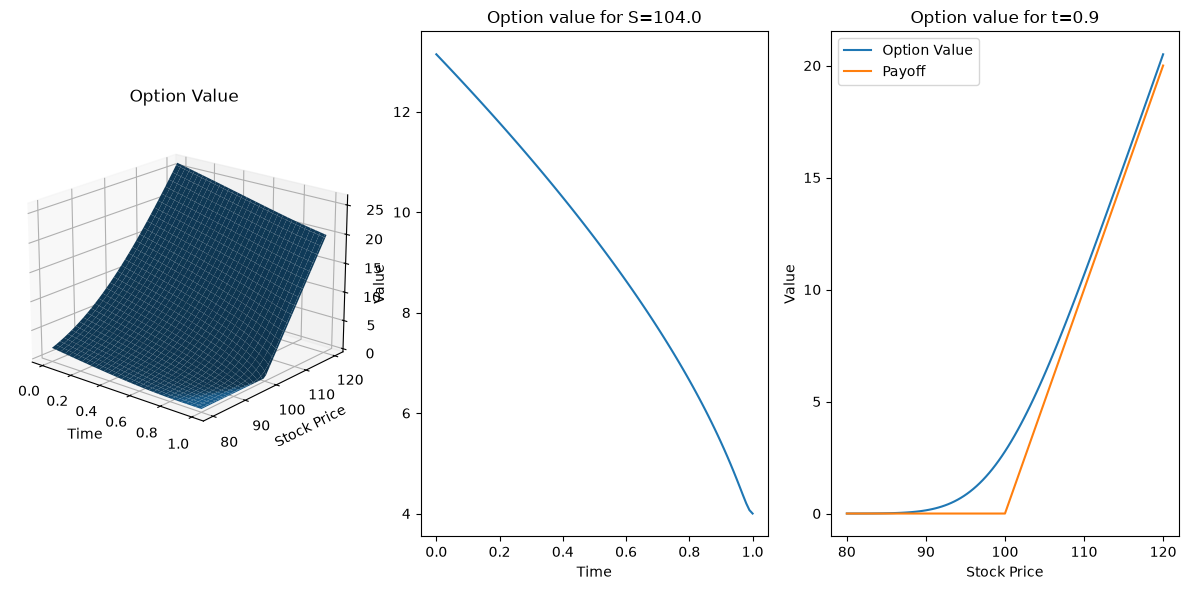

In [2]:
# Initialise variables
T = 1
K = 100
r = 0.05
sigma = 0.2

# Create the time and stock domain
t = np.linspace(0,T,101)
S = np.linspace(80,120,101)
t, S = np.meshgrid(t, S)

# For readibility, we will define the terms inside the normal CDF
a = (np.log(S/K) + (r+sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
b = (np.log(S/K) + (r-sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)

V = S * sp.stats.norm.cdf(a) - K * np.exp(-r*(T-t)) * sp.stats.norm.cdf(b)

fig = plt.figure(figsize=(12,6))

ax1 = fig.add_subplot(1, 3, 1, projection='3d')
ax1.plot_surface(t, S, V)
ax1.set_title('Option Value')
ax1.set_xlabel('Time')
ax1.set_ylabel('Stock Price')
ax1.view_init(elev=20, azim=-50)

ax2 = fig.add_subplot(1,3,2)
ax2.plot(t[0], V[60,:])
ax2.set_title(f'Option value for S={S[60,0]}')
ax2.set_xlabel('Time')
ax2.set_ylabel('Value')

ax3 = fig.add_subplot(1,3,3)
ax3.plot(S[:,0], V[:, 90])
ax3.plot(S[:,0], np.maximum(S[:,0]-K, 0))
ax3.set_title(f'Option value for t={t[0,90]}')
ax3.set_xlabel('Stock Price')
ax3.set_ylabel('Value')
ax3.legend(['Option Value', 'Payoff'])

plt.tight_layout()
plt.show()

### Benchmarking

In this section we will employ several tests of our numerical methods. The following are not intended as rigorous convergence checks (these will come later) but should be thought of as quick sanity checks. We will check:
1. Both the Crank-Nicholson solver and the binomial tree solver agree with the analytic solution for both European calls and puts.
2. We will compare the numeric American call options to their analytic European counterpart. It can be shown that in the case of no dividends, that these two options should be priced equally.
3. We will verify that, for an American put, it's value is always greater than its European counterpart.
4. We further verify that the American put's value satisifes $\max{(K-S, 0)}\leq V(S,t)\leq K$.

#### Benchmark 1

We will conduct this using the parameters $K=100, r=0.05, \sigma=0.2, T=1$. For the Crank-Nicholson solver, we choose an upper bound of $400$. For the Binomial tree, we choose $S_0=95$.

In [21]:
V_CN_call = BS_solver_crank_nicholson(S_upper=400, T=1, K=100, r=0.05, sigma=0.2, put=False, American=False, m=1000, n=1000)
V_CN_put = BS_solver_crank_nicholson(S_upper=400, T=1, K=100, r=0.05, sigma=0.2, put=True, American=False, m=1000, n=1000)

n = 1000
m = 1000
S_upper = 400
T = 1
K = 100
r = 0.05
sigma = 0.2

# Create the time and stock domain
t = np.linspace(0,T,n+1)
S = np.linspace(0,S_upper,m+1)
t, S = np.meshgrid(t, S)

# For readibility, we will define the terms inside the normal CDF
a = (np.log(S/K) + (r+sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
b = (np.log(S/K) + (r-sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)

V_analytic_call = S * sp.stats.norm.cdf(a) - K * np.exp(-r*(T-t)) * sp.stats.norm.cdf(b)
V_analytic_put = -S * sp.stats.norm.cdf(-a) + K * np.exp(-r*(T-t)) * sp.stats.norm.cdf(-b)

# The analytical solution encounters a division by 0 at the terminal condition when t=T and when the S
print( f'Maximum absolute error for European call for Crank-Nicholson method: {np.nanmax(np.abs(V_CN_call-V_analytic_call)) :.3f}' )
print( f'Maximum absolute error for European put for Crank-Nicholson method: {np.nanmax(np.abs(V_CN_put-V_analytic_put)) :.3f}' )

C:\Users\ccbar\AppData\Local\Temp\ipykernel_3884\1942916852.py:18: RuntimeWarning: divide by zero encountered in log
  a = (np.log(S/K) + (r+sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
C:\Users\ccbar\AppData\Local\Temp\ipykernel_3884\1942916852.py:18: RuntimeWarning: divide by zero encountered in divide
  a = (np.log(S/K) + (r+sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
C:\Users\ccbar\AppData\Local\Temp\ipykernel_3884\1942916852.py:18: RuntimeWarning: invalid value encountered in divide
  a = (np.log(S/K) + (r+sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
C:\Users\ccbar\AppData\Local\Temp\ipykernel_3884\1942916852.py:19: RuntimeWarning: divide by zero encountered in log
  b = (np.log(S/K) + (r-sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
C:\Users\ccbar\AppData\Local\Temp\ipykernel_3884\1942916852.py:19: RuntimeWarning: divide by zero encountered in divide
  b = (np.log(S/K) + (r-sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
C:\Users\ccbar\AppData\Local\Temp\ipykernel_3884\1942916852.py:19: RuntimeWarning: invalid value 

Maximum absolute error for European call for Crank-Nicholson method: 0.020
Maximum absolute error for European put for Crank-Nicholson method: 0.020


In [22]:
V_BT_call = BS_solver_binomial_tree(S0=95, T=1, K=100, r=0.05, sigma=0.2, put=False, American=False, n=1000)
V_BT_put = BS_solver_binomial_tree(S0=95, T=1, K=100, r=0.05, sigma=0.2, put=False, American=False, n=1000)

n = 1000
S0 = 95
T = 1
K = 100
r = 0.05
sigma = 0.2
dt = T/n
u = np.exp(sigma*np.sqrt(dt))
d = np.exp(-sigma*np.sqrt(dt))

# Create the time and stock domain
t = np.linspace(0, T, n+1)
S = np.array([ np.array([S0*u**(j-i)*d**i for i in range(j+1)]+([0]*(n-j))) for j in range(n+1) ]).T

a = (np.log(S/K) + (r+sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
b = (np.log(S/K) + (r-sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)

V_analytic_call = S * sp.stats.norm.cdf(a) - K * np.exp(-r*(T-t)) * sp.stats.norm.cdf(b)
V_analytic_put = -S * sp.stats.norm.cdf(-a) + K * np.exp(-r*(T-t)) * sp.stats.norm.cdf(-b)

print( f'Maximum absolute error for European call for Binomial tree method: {np.nanmax(np.abs(V_BT_call-V_analytic_call)) :.3f}' )
print( f'Maximum absolute error for European put for Binomial tree method: {np.nanmax(np.abs(V_BT_put-V_analytic_call)) :.3f}' )

C:\Users\ccbar\AppData\Local\Temp\ipykernel_3884\2654379699.py:18: RuntimeWarning: divide by zero encountered in log
  a = (np.log(S/K) + (r+sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
C:\Users\ccbar\AppData\Local\Temp\ipykernel_3884\2654379699.py:18: RuntimeWarning: divide by zero encountered in divide
  a = (np.log(S/K) + (r+sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
C:\Users\ccbar\AppData\Local\Temp\ipykernel_3884\2654379699.py:19: RuntimeWarning: divide by zero encountered in log
  b = (np.log(S/K) + (r-sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
C:\Users\ccbar\AppData\Local\Temp\ipykernel_3884\2654379699.py:19: RuntimeWarning: divide by zero encountered in divide
  b = (np.log(S/K) + (r-sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)


Maximum absolute error for European call for Binomial tree method: 0.043
Maximum absolute error for European put for Binomial tree method: 0.043


#### Benchmark 2

Here we will consider the case of the American call option. When there are no dividend payments, it can be shown that the American call ought never to be exercised. It thus has equal value to its European counterpart. We use this result to benchmark our American call options for both the Crank-Nicholson method and the binomial tree.

In [31]:
# Crank-Nicholson
#V_CN_call = BS_solver_crank_nicholson(S_upper=400, T=1, K=100, r=0.05, sigma=0.2, put=False, American=True, m=1000, n=1000)

n = 10000
m = 1000
S_upper = 400
T = 1
K = 100
r = 0.05
sigma = 0.2

# Create the time and stock domain
t = np.linspace(0,T,n+1)
S = np.linspace(0,S_upper,m+1)
t, S = np.meshgrid(t, S)

# For readibility, we will define the terms inside the normal CDF
a = (np.log(S/K) + (r+sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
b = (np.log(S/K) + (r-sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)

V_analytic_call = S * sp.stats.norm.cdf(a) - K * np.exp(-r*(T-t)) * sp.stats.norm.cdf(b)
V_analytic_put =  -S* sp.stats.norm.cdf(-a) + K * np.exp(-r*(T-t)) * sp.stats.norm.cdf(-b)

# The analytical solution encounters a division by 0 at the terminal condition when t=T and when the S
#print( f'Maximum absolute error for American call for Crank-Nicholson method: {np.nanmax(np.abs(V_CN_call-V_analytic_call)) :.3f}' )

C:\Users\ccbar\AppData\Local\Temp\ipykernel_22860\3936015102.py:18: RuntimeWarning: divide by zero encountered in log
  a = (np.log(S/K) + (r+sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
C:\Users\ccbar\AppData\Local\Temp\ipykernel_22860\3936015102.py:18: RuntimeWarning: divide by zero encountered in divide
  a = (np.log(S/K) + (r+sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
C:\Users\ccbar\AppData\Local\Temp\ipykernel_22860\3936015102.py:18: RuntimeWarning: invalid value encountered in divide
  a = (np.log(S/K) + (r+sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
C:\Users\ccbar\AppData\Local\Temp\ipykernel_22860\3936015102.py:19: RuntimeWarning: divide by zero encountered in log
  b = (np.log(S/K) + (r-sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
C:\Users\ccbar\AppData\Local\Temp\ipykernel_22860\3936015102.py:19: RuntimeWarning: divide by zero encountered in divide
  b = (np.log(S/K) + (r-sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
C:\Users\ccbar\AppData\Local\Temp\ipykernel_22860\3936015102.py:19: RuntimeWarning: invalid 

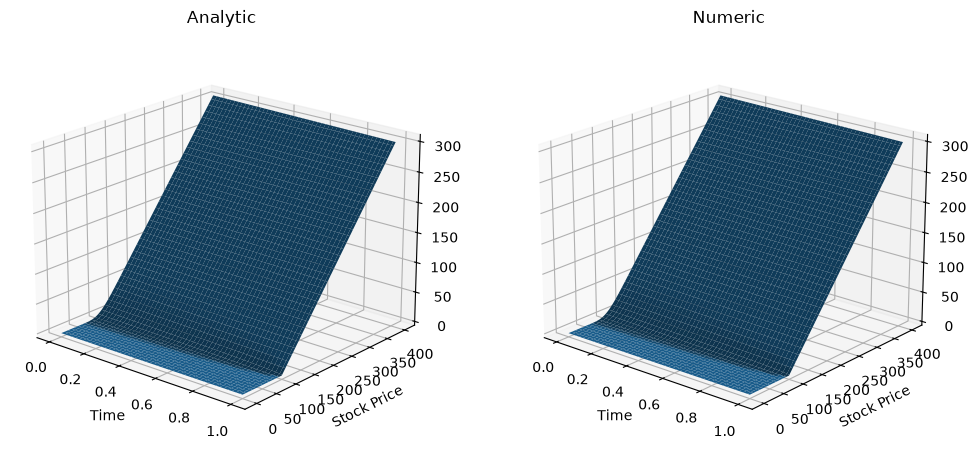

In [3]:
fig = plt.figure(figsize=(12,6))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(t, S, V_analytic_call)
ax1.set_title('Analytic')
ax1.set_xlabel('Time')
ax1.set_ylabel('Stock Price')
ax1.view_init(elev=20, azim=-50)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(t, S, V_CN_call)
ax2.set_title('Numeric')
ax2.set_xlabel('Time')
ax2.set_ylabel('Stock Price')
ax2.view_init(elev=20, azim=-50)

In [23]:
V_BT_call = BS_solver_binomial_tree(S0=95, T=1, K=100, r=0.05, sigma=0.2, put=False, American=True, n=1000)

n = 1000
S0 = 95
T = 1
K = 100
r = 0.05
sigma = 0.2
dt = T/n
u = np.exp(sigma*np.sqrt(dt))
d = np.exp(-sigma*np.sqrt(dt))

# Create the time and stock domain
t = np.linspace(0, T, n+1)
S = np.array([ np.array([S0*u**(j-i)*d**i for i in range(j+1)]+([0]*(n-j))) for j in range(n+1) ]).T

a = (np.log(S/K) + (r+sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
b = (np.log(S/K) + (r-sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)

V_analytic_call = S * sp.stats.norm.cdf(a) - K * np.exp(-r*(T-t)) * sp.stats.norm.cdf(b)

print( f'Maximum absolute error for American call for binomial tree method: {np.nanmax(np.abs(V_BT_call-V_analytic_call)) :.3f}' )

C:\Users\ccbar\AppData\Local\Temp\ipykernel_3884\3252532219.py:17: RuntimeWarning: divide by zero encountered in log
  a = (np.log(S/K) + (r+sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
C:\Users\ccbar\AppData\Local\Temp\ipykernel_3884\3252532219.py:17: RuntimeWarning: divide by zero encountered in divide
  a = (np.log(S/K) + (r+sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
C:\Users\ccbar\AppData\Local\Temp\ipykernel_3884\3252532219.py:18: RuntimeWarning: divide by zero encountered in log
  b = (np.log(S/K) + (r-sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)
C:\Users\ccbar\AppData\Local\Temp\ipykernel_3884\3252532219.py:18: RuntimeWarning: divide by zero encountered in divide
  b = (np.log(S/K) + (r-sigma**2/2)*(T-t))/sigma/np.sqrt(T-t)


Maximum absolute error for American call for binomial tree method: 0.043


#### Benchmark 3

In [30]:
V_CN_put = BS_solver_crank_nicholson(S_upper=400, T=1, K=100, r=0.05, sigma=0.2, put=True, American=True, m=1000, n=10000)

In [69]:
eps = 1e-1
print( f'American put greater than European put for all values: {np.all(np.where(np.isnan(V_CN_put) | np.isnan(V_analytic_put), True, V_CN_put + eps >= V_analytic_put))}' )

American put greater than European put for all values: True


In [38]:
np.where(V_CN_put < V_analytic_put)

(array([ 248,  248,  248, ..., 1000, 1000, 1000], shape=(203980,)),
 array([9925, 9926, 9927, ..., 9659, 9660, 9661], shape=(203980,)))

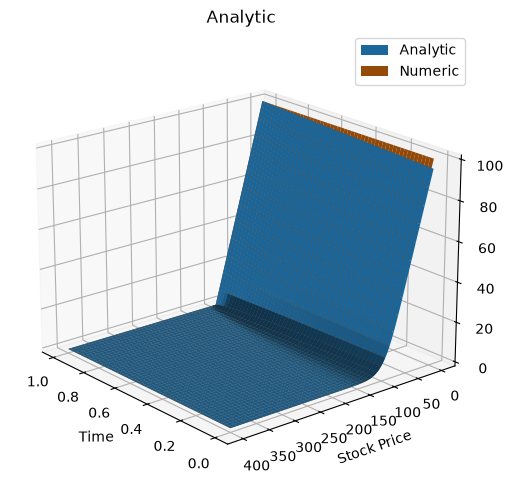

In [39]:
fig = plt.figure(figsize=(12,6))

ax1 = fig.add_subplot(1, 1, 1, projection='3d')
ax1.plot_surface(t, S, V_analytic_put)
ax1.plot_surface(t, S, V_CN_put)
ax1.set_title('Analytic')
ax1.set_xlabel('Time')
ax1.set_ylabel('Stock Price')
ax1.view_init(elev=20, azim=140)
ax1.legend(['Analytic', 'Numeric'])



In [24]:
V_BT_put = BS_solver_binomial_tree(S0=95, T=1, K=100, r=0.05, sigma=0.2, put=True, American=True, n=1000)

n = 1000
S0 = 95
T = 1
K = 100
r = 0.05
sigma = 0.2
dt = T/n
u = np.exp(sigma*np.sqrt(dt))
d = np.exp(-sigma*np.sqrt(dt))

# Create the time and stock domain
t = np.linspace(0, T, n+1)
S = np.array([ np.array([S0*u**(j-i)*d**i for i in range(j+1)]+([0]*(n-j))) for j in range(n+1) ]).T

V_analytic_put = np.zeros((n+1, n+1))
payoff = np.zeros((n+1, n+1))

for j in range(n+1):
    a = (np.log(S[0:j+1, j]/K) + (r+sigma**2/2)*(T-t[j]))/sigma/np.sqrt(T-t[j])*np.ones(j+1)
    b = (np.log(S[0:j+1, j]/K) + (r-sigma**2/2)*(T-t[j]))/sigma/np.sqrt(T-t[j])*np.ones(j+1)
    V_analytic_put[0:j+1, j] = - S[0:j+1, j] * sp.stats.norm.cdf(-a) + K * np.exp(-r*(T-t[j])) * sp.stats.norm.cdf(-b)
    payoff[0:j+1, j] = np.maximum(K - S[0:j+1, j], 0)

eps = 1e-1
print( f'American put greater than European put for all values: {np.all(V_BT_put + eps >= V_analytic_put)}' )


American put greater than European put for all values: True


C:\Users\ccbar\AppData\Local\Temp\ipykernel_3884\196776348.py:21: RuntimeWarning: divide by zero encountered in divide
  a = (np.log(S[0:j+1, j]/K) + (r+sigma**2/2)*(T-t[j]))/sigma/np.sqrt(T-t[j])*np.ones(j+1)
C:\Users\ccbar\AppData\Local\Temp\ipykernel_3884\196776348.py:22: RuntimeWarning: divide by zero encountered in divide
  b = (np.log(S[0:j+1, j]/K) + (r-sigma**2/2)*(T-t[j]))/sigma/np.sqrt(T-t[j])*np.ones(j+1)


#### Benchmark 4

In [41]:
n=10000
m=1000
payoff = np.zeros((m+1, n+1))
for j in range(m+1):
    payoff[:, j] = np.maximum(K - S[:, j], 0)

eps = 0
print( f'American put bounded above by K: {np.all(V_CN_put <= K+eps)}' )
print( f'American put bounded below by payoff: {np.all(V_CN_put +eps >= payoff)}' )

American put bounded above by K: True
American put bounded below by payoff: True


In [44]:
S.shape

(1001, 10001)

In [42]:
eps = 1e-12
print( f'American put bounded above by K: {np.all(V_BT_put <= K+eps)}' )
print( f'American put bounded below by payoff: {np.all(V_BT_put +eps >= payoff)}' )

NameError: name 'V_BT_put' is not defined

1.0


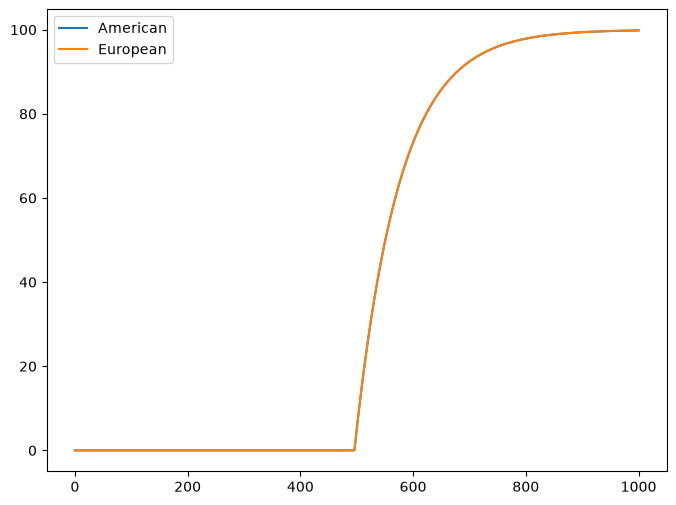

In [26]:
k=10
eps = 1e-3

fig, ax = plt.subplots(1,1, figsize=(8,6))

ax.plot(V_BT_put[:,100*k])
ax.plot(V_analytic_put[:,100*k])
ax.legend(['American', 'European'])

print(np.mean(V_BT_put[:,100*k]+eps>=V_analytic_put[:,100*k]))

1.0


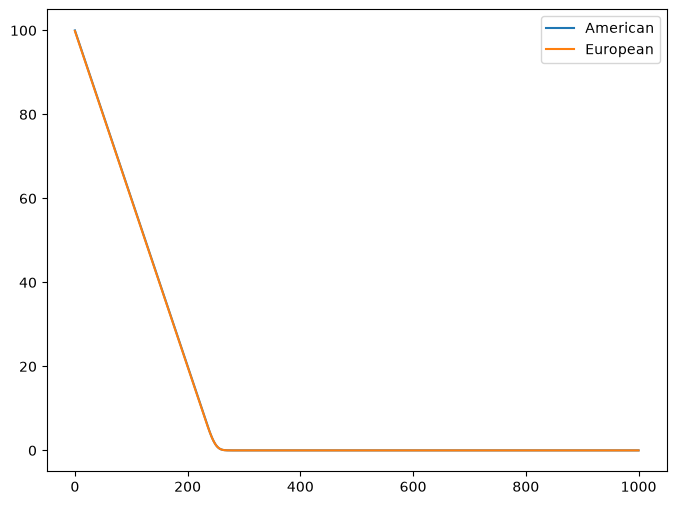

In [ ]:
k=97
eps = 1e-3
fig, ax = plt.subplots(1,1, figsize=(8,6))
ax.plot(V_CN_put[:,100*k])
ax.plot(V_analytic_put[:,100*k])
ax.legend(['American', 'European'])
print(np.mean(V_CN_put[:,100*k]+eps>=V_analytic_put[:,100*k])b)

In [60]:
eps=100000000000000000000000000
np.mean(V_CN_put+eps>=V_analytic_put)

np.float64(0.9999999001098892)

In [61]:
np.max(V_analytic_put)

np.float64(nan)

### Convergence Analysis

### Greeks Calculation

### Comparison With Market Data